# 1. Imports


In [2]:
import os
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

## 1.1 Kiezen cough om te replicaten

In [3]:
import shutil
import os

os.makedirs("generated/reference", exist_ok=True)

shutil.copy(
    "data/sounds/sounds/fe3424345a76c/cough_segmented/seg4_processed.wav",
    "generated/reference/reference_cough.wav"
)


'generated/reference/reference_cough.wav'

# 2. Referentie cough inladen

c:\Users\briek\.virtualenvs\Deep_learning_project-8qJO88P_\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Duur: 2.0 seconden
Sample rate: 16000


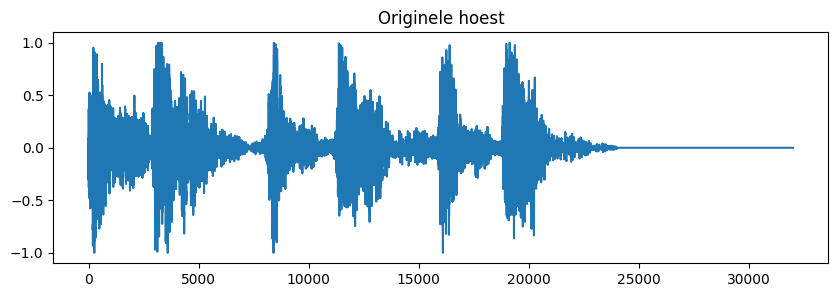

In [4]:
# dit is de hoest die we gaan reconstrueren
fp = "generated/reference/reference_cough.wav"

y, sr = librosa.load(fp, sr=16000)
print("Duur:", round(len(y)/sr, 2), "seconden")
print("Sample rate:", sr)

plt.figure(figsize=(10, 3))
plt.plot(y)
plt.title("Originele hoest")
plt.show()

# 3. Mel spectrogram maken van de referentie

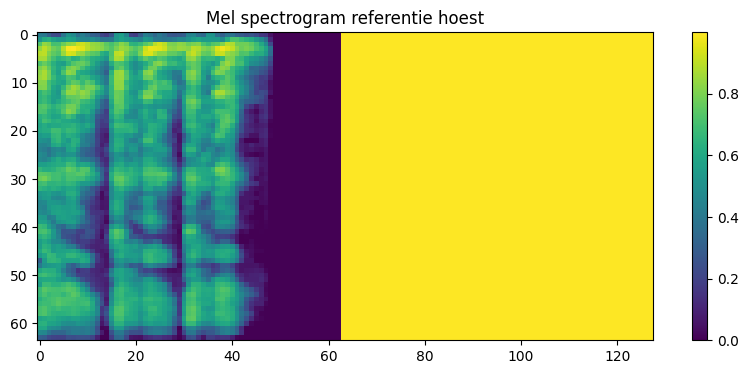

Spectrogram shape: (64, 128)


In [13]:
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, n_fft=2048, hop_length=512)
mel_db = librosa.power_to_db(mel, ref=np.max)

if mel_db.shape[1] < 128:
    pad = np.zeros((64, 128 - mel_db.shape[1]))
    mel_db = np.hstack([mel_db, pad])
else:
    mel_db = mel_db[:, :128]

mel_min = mel_db.min()
mel_max = mel_db.max()
mel_norm = (mel_db - mel_min) / (mel_max - mel_min + 1e-8)

plt.figure(figsize=(10, 4))
plt.imshow(mel_norm)
plt.title("Mel spectrogram referentie hoest")
plt.colorbar()
plt.show()

print("Spectrogram shape:", mel_norm.shape)

Dat gele is padding, die moet eigenlijk weg: 

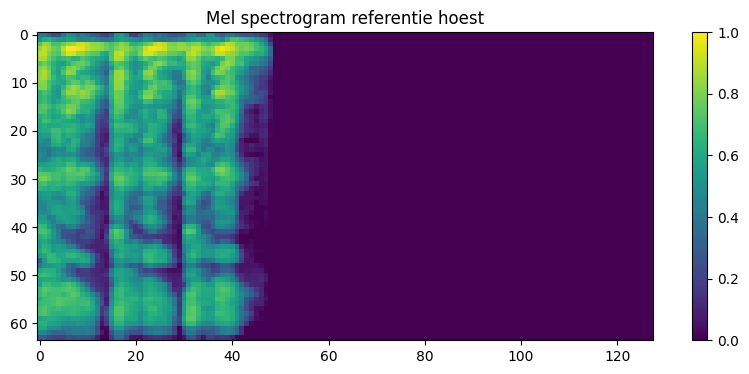

Spectrogram shape: (64, 128)


In [14]:
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, n_fft=2048, hop_length=512)
mel_db = librosa.power_to_db(mel, ref=np.max)

# normaliseren VOOR het padden
mel_min = mel_db.min()
mel_max = mel_db.max()
mel_norm = (mel_db - mel_min) / (mel_max - mel_min + 1e-8)

if mel_norm.shape[1] < 128:
    pad = np.zeros((64, 128 - mel_norm.shape[1]))
    mel_norm = np.hstack([mel_norm, pad])
else:
    mel_norm = mel_norm[:, :128]

plt.figure(figsize=(10, 4))
plt.imshow(mel_norm)
plt.title("Mel spectrogram referentie hoest")
plt.colorbar()
plt.show()

print("Spectrogram shape:", mel_norm.shape)

# 4. Autoencoder bouwen

In [15]:
#encoder
input_img = layers.Input(shape=(64, 128, 1))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)


# dcoder
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# volledige auto-encoder
autoencoder = Model(input_img, decoded)
autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 32, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 16, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 16, 8)       │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 16, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 32, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 32, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 128, 1)     │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,785 (49.94 KB)

 Trainable params: 12,785 (49.94 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Aparte encoder en decoder

In [16]:
# encoder geeft latent space terug
encoder = Model(input_img, encoded)

# decoder 
latent_input = layers.Input(shape=(8, 16, 8))
x = autoencoder.layers[-7](latent_input)
x = autoencoder.layers[-6](x)
x = autoencoder.layers[-5](x)
x = autoencoder.layers[-4](x)
x = autoencoder.layers[-3](x)
x = autoencoder.layers[-2](x)
decoder_output = autoencoder.layers[-1](x)

decoder = Model(latent_input, decoder_output)

print("Encoder output shape:", encoder.output_shape)
print("Decoder output shape:", decoder.output_shape)

Encoder output shape: (None, 8, 16, 8)
Decoder output shape: (None, 64, 128, 1)


# 6. Trainen op enkel onze referentie hoest

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1758
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.1749
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1741
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.1733
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1724
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1713
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1698
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1681
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1659
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1633
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.1599
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1558
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1507
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1444
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1367
Epoch 16/500
1/1 ━━━━

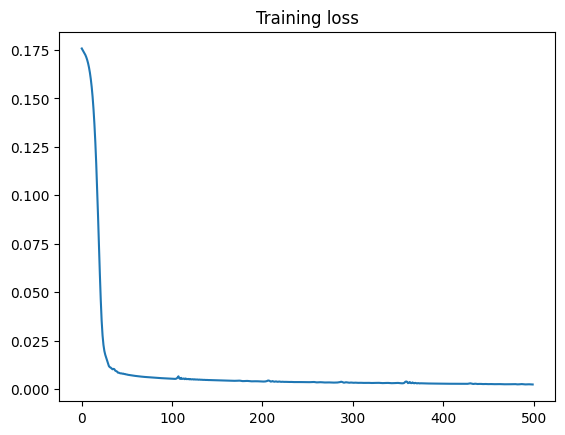

In [17]:
X_ref = mel_norm[np.newaxis, ..., np.newaxis].astype(np.float32)

autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(
    X_ref, X_ref,
    epochs=500,
    batch_size=1,
    verbose=1
)

plt.plot(history.history['loss'])
plt.title('Training loss')
plt.show()

# 8. Reconstructie bekijken


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step


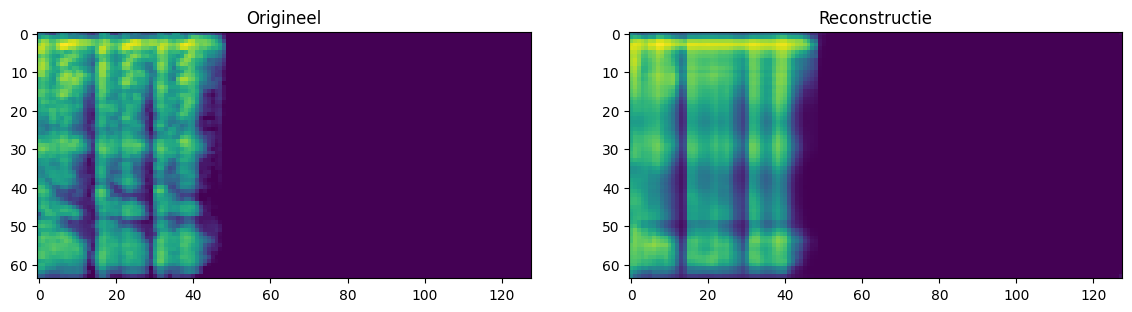

In [18]:
reconstructie = autoencoder.predict(X_ref)[0, :, :, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(mel_norm)
axes[0].set_title('Origineel')
axes[1].imshow(reconstructie)
axes[1].set_title('Reconstructie')
plt.show()

# 9. Naar wav omzetten en opslaan

In [19]:
D_orig = librosa.stft(y, n_fft=2048, hop_length=512)
fase_orig = np.angle(D_orig)

mel_db_recon = reconstructie * (mel_max - mel_min) + mel_min
mel_power = librosa.db_to_power(mel_db_recon)

mel_filters = librosa.filters.mel(sr=16000, n_fft=2048, n_mels=64)
stft_matrix = np.dot(np.linalg.pinv(mel_filters), mel_power)

stft_matrix = stft_matrix[:, :fase_orig.shape[1]]
audio_recon = librosa.istft(
    stft_matrix * np.exp(1j * fase_orig),
    hop_length=512
)

audio_recon = audio_recon / (np.max(np.abs(audio_recon)) + 1e-8)
y_norm = y / (np.max(np.abs(y)) + 1e-8)

sf.write("generated/origineel.wav", y_norm, 16000)
sf.write("generated/reconstructie.wav", audio_recon, 16000)


Sommige van deze code zijn met behulp van AI gemaakt, puur omdat we geen idee hadden hoe dat we met audio moet omgaan (Vooral alle mathematische zaken). Maar het was wel een leuke uitdaging die we eens wouden proberen.